# Devin Booker — 2024-25 Season Deep Dive
Full breakdown of Booker's stats, trends, splits, and tendencies across 60 games.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PATH = '/Users/evanjohnson/Documents/personal/NBA_Statistics/NBA_Statistics/2025_player_data/Devin Booker.csv'

df = pd.read_csv(PATH, encoding='utf-8')
numeric_cols = ['Margin','Minutes','FGA','FGM','3PA','3PM','FT','FTA',
                'ORB','TRB','Assists','Steals','Blocks','Turnovers','Fouls','Points','p/m']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df['Game'] = df.index + 1
df['Home'] = df['Home(0)/Away(1)'] == 0
df['Win'] = df['Margin'] > 0
df['FG%'] = df['FGM'] / df['FGA']
df['3P%'] = df['3PM'] / df['3PA']
df['FT%'] = df['FT'] / df['FTA']
df['Month'] = df['Date'].dt.strftime('%b')
df['Month_num'] = df['Date'].dt.month

print(f"Games loaded: {len(df)}")
print(f"Season span: {df['Date'].min().date()} → {df['Date'].max().date()}")
df.head(3)

Games loaded: 60
Season span: 2024-10-23 → 2025-03-12


,Date,Team,Opponent,Home(0)/Away(1),Margin,Minutes,FGA,FGM,3PA,3PM,...,Points,p/m,Game,Home,Win,FG%,3P%,FT%,Month,Month_num
0,2024-10-23,PHO,LAC,1,3,32.13,9,5,5,4,...,15,-4,1,False,True,0.555556,0.80,0.500000,Oct,10
1,2024-10-25,PHO,LAL,1,-7,35.33,21,9,10,4,...,23,-10,2,False,False,0.428571,0.40,0.500000,Oct,10
2,2024-10-26,PHO,DAL,0,12,37.08,12,4,8,2,...,21,7,3,True,True,0.333333,0.25,0.916667,Oct,10


## Season Summary

In [2]:
gp   = len(df)
wins = df['Win'].sum()
ppg  = df['Points'].mean()
apg  = df['Assists'].mean()
rpg  = df['TRB'].mean()
spg  = df['Steals'].mean()
bpg  = df['Blocks'].mean()
tpg  = df['Turnovers'].mean()
mpg  = df['Minutes'].mean()
pm   = df['p/m'].mean()
fg   = df['FGM'].sum() / df['FGA'].sum()
tp   = df['3PM'].sum() / df['3PA'].sum()
ft   = df['FT'].sum()  / df['FTA'].sum()

summary = pd.Series({
    'Games Played': gp,
    'Record (in these games)': f"{int(wins)}-{int(gp-wins)}",
    'Points': round(ppg, 1),
    'Assists': round(apg, 1),
    'Rebounds': round(rpg, 1),
    'Steals': round(spg, 2),
    'Blocks': round(bpg, 2),
    'Turnovers': round(tpg, 1),
    'Minutes': round(mpg, 1),
    'Plus/Minus': round(pm, 1),
    'FG%': f"{fg:.1%}",
    '3P%': f"{tp:.1%}",
    'FT%': f"{ft:.1%}",
})

print('='*35)
print('  DEVIN BOOKER — 2024-25 SEASON')
print('='*35)
for k, v in summary.items():
    print(f"  {k:<28} {v}")
print('='*35)

  DEVIN BOOKER — 2024-25 SEASON
  Games Played                 60
  Record (in these games)      29-31
  Points                       25.8
  Assists                      6.8
  Rebounds                     4.1
  Steals                       1.03
  Blocks                       0.23
  Turnovers                    2.8
  Minutes                      37.5
  Plus/Minus                   -1.7
  FG%                          45.7%
  3P%                          34.6%
  FT%                          88.9%


## Points Per Game — Full Season

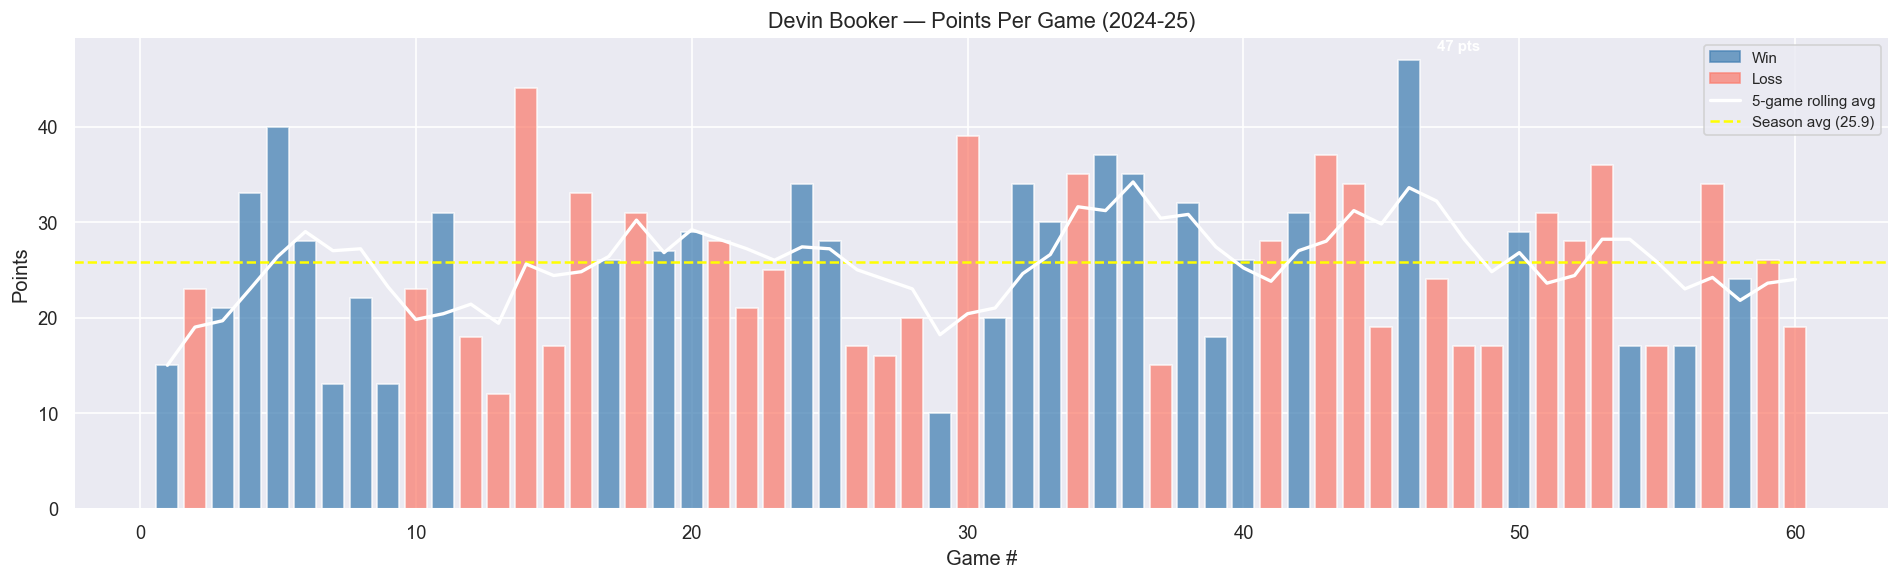

In [3]:
fig, ax = plt.subplots(figsize=(16, 5))

# color bars by win/loss
colors = ['steelblue' if w else 'salmon' for w in df['Win']]
ax.bar(df['Game'], df['Points'], color=colors, alpha=0.75, width=0.8)
ax.plot(df['Game'], df['Points'].rolling(5, min_periods=1).mean(),
        color='white', lw=2, label='5-game rolling avg', zorder=3)
ax.axhline(ppg, color='yellow', lw=1.5, linestyle='--', label=f'Season avg ({ppg:.1f})')

# annotate career highs
peak = df['Points'].idxmax()
ax.annotate(f"{int(df.loc[peak,'Points'])} pts",
            xy=(df.loc[peak,'Game'], df.loc[peak,'Points']),
            xytext=(df.loc[peak,'Game']+1, df.loc[peak,'Points']+1),
            fontsize=9, color='white', fontweight='bold')

blue_p  = mpatches.Patch(color='steelblue', alpha=0.75, label='Win')
red_p   = mpatches.Patch(color='salmon',    alpha=0.75, label='Loss')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[blue_p, red_p] + handles, fontsize=9)

ax.set_xlabel('Game #')
ax.set_ylabel('Points')
ax.set_title('Devin Booker — Points Per Game (2024-25)', fontsize=13)
plt.tight_layout()
plt.show()

## Rolling Averages — Points / Assists / Rebounds

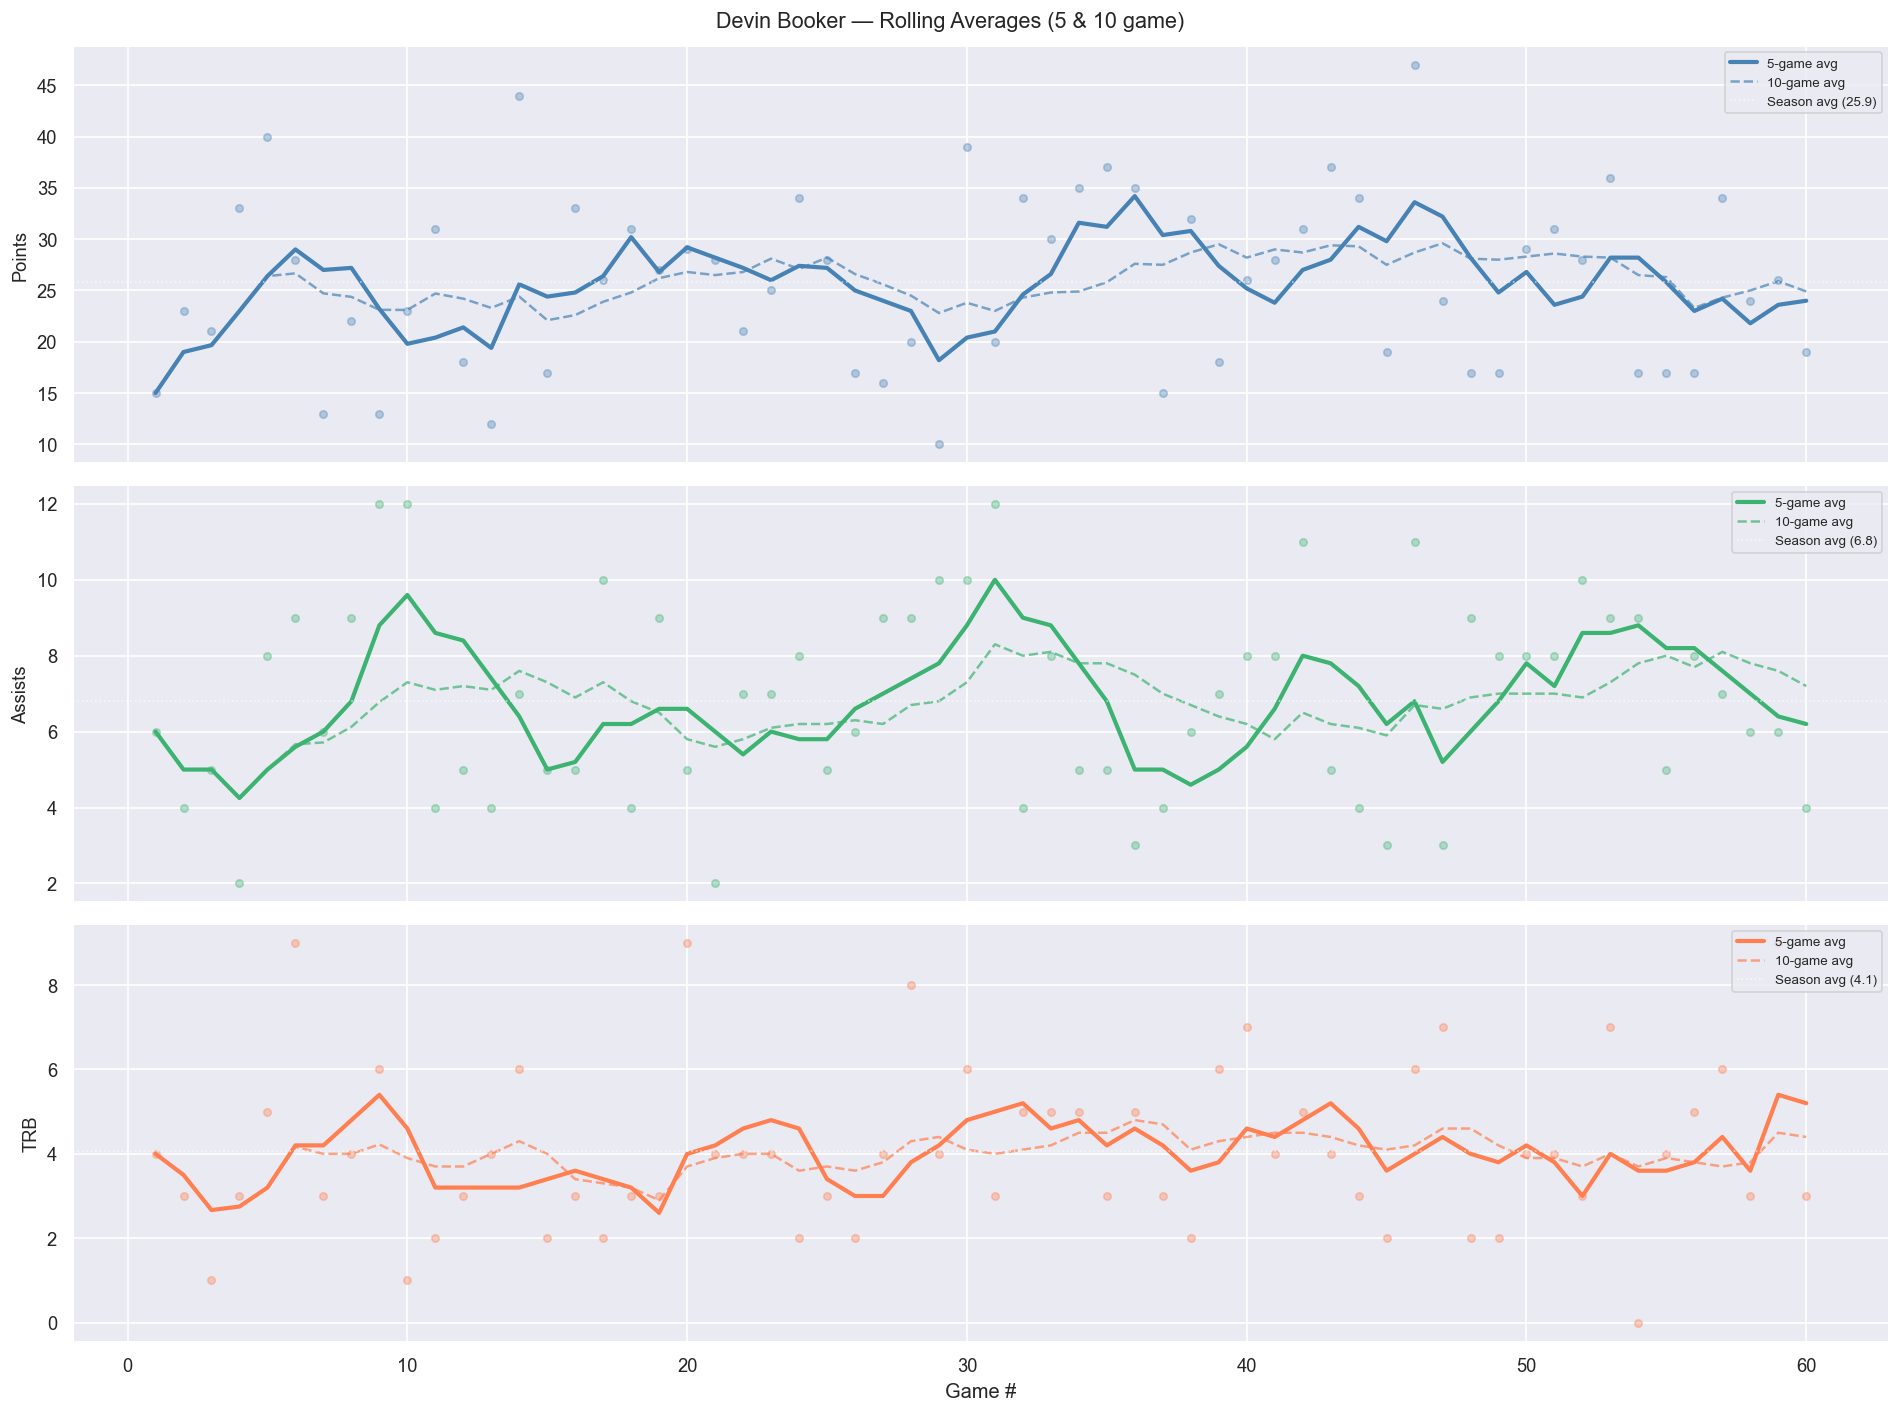

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, stat, color, avg in [
    (axes[0], 'Points',  'steelblue',      ppg),
    (axes[1], 'Assists', 'mediumseagreen',  apg),
    (axes[2], 'TRB',     'coral',           rpg),
]:
    ax.scatter(df['Game'], df[stat], alpha=0.35, s=20, color=color)
    ax.plot(df['Game'], df[stat].rolling(5, min_periods=1).mean(),
            color=color, lw=2.5, label='5-game avg')
    ax.plot(df['Game'], df[stat].rolling(10, min_periods=1).mean(),
            color=color, lw=1.5, linestyle='--', alpha=0.7, label='10-game avg')
    ax.axhline(avg, color='white', lw=1, linestyle=':', alpha=0.6, label=f'Season avg ({avg:.1f})')
    ax.set_ylabel(stat, fontsize=11)
    ax.legend(fontsize=8, loc='upper right')

axes[2].set_xlabel('Game #')
plt.suptitle('Devin Booker — Rolling Averages (5 & 10 game)', fontsize=13)
plt.tight_layout()
plt.show()

## Shooting Efficiency Over the Season

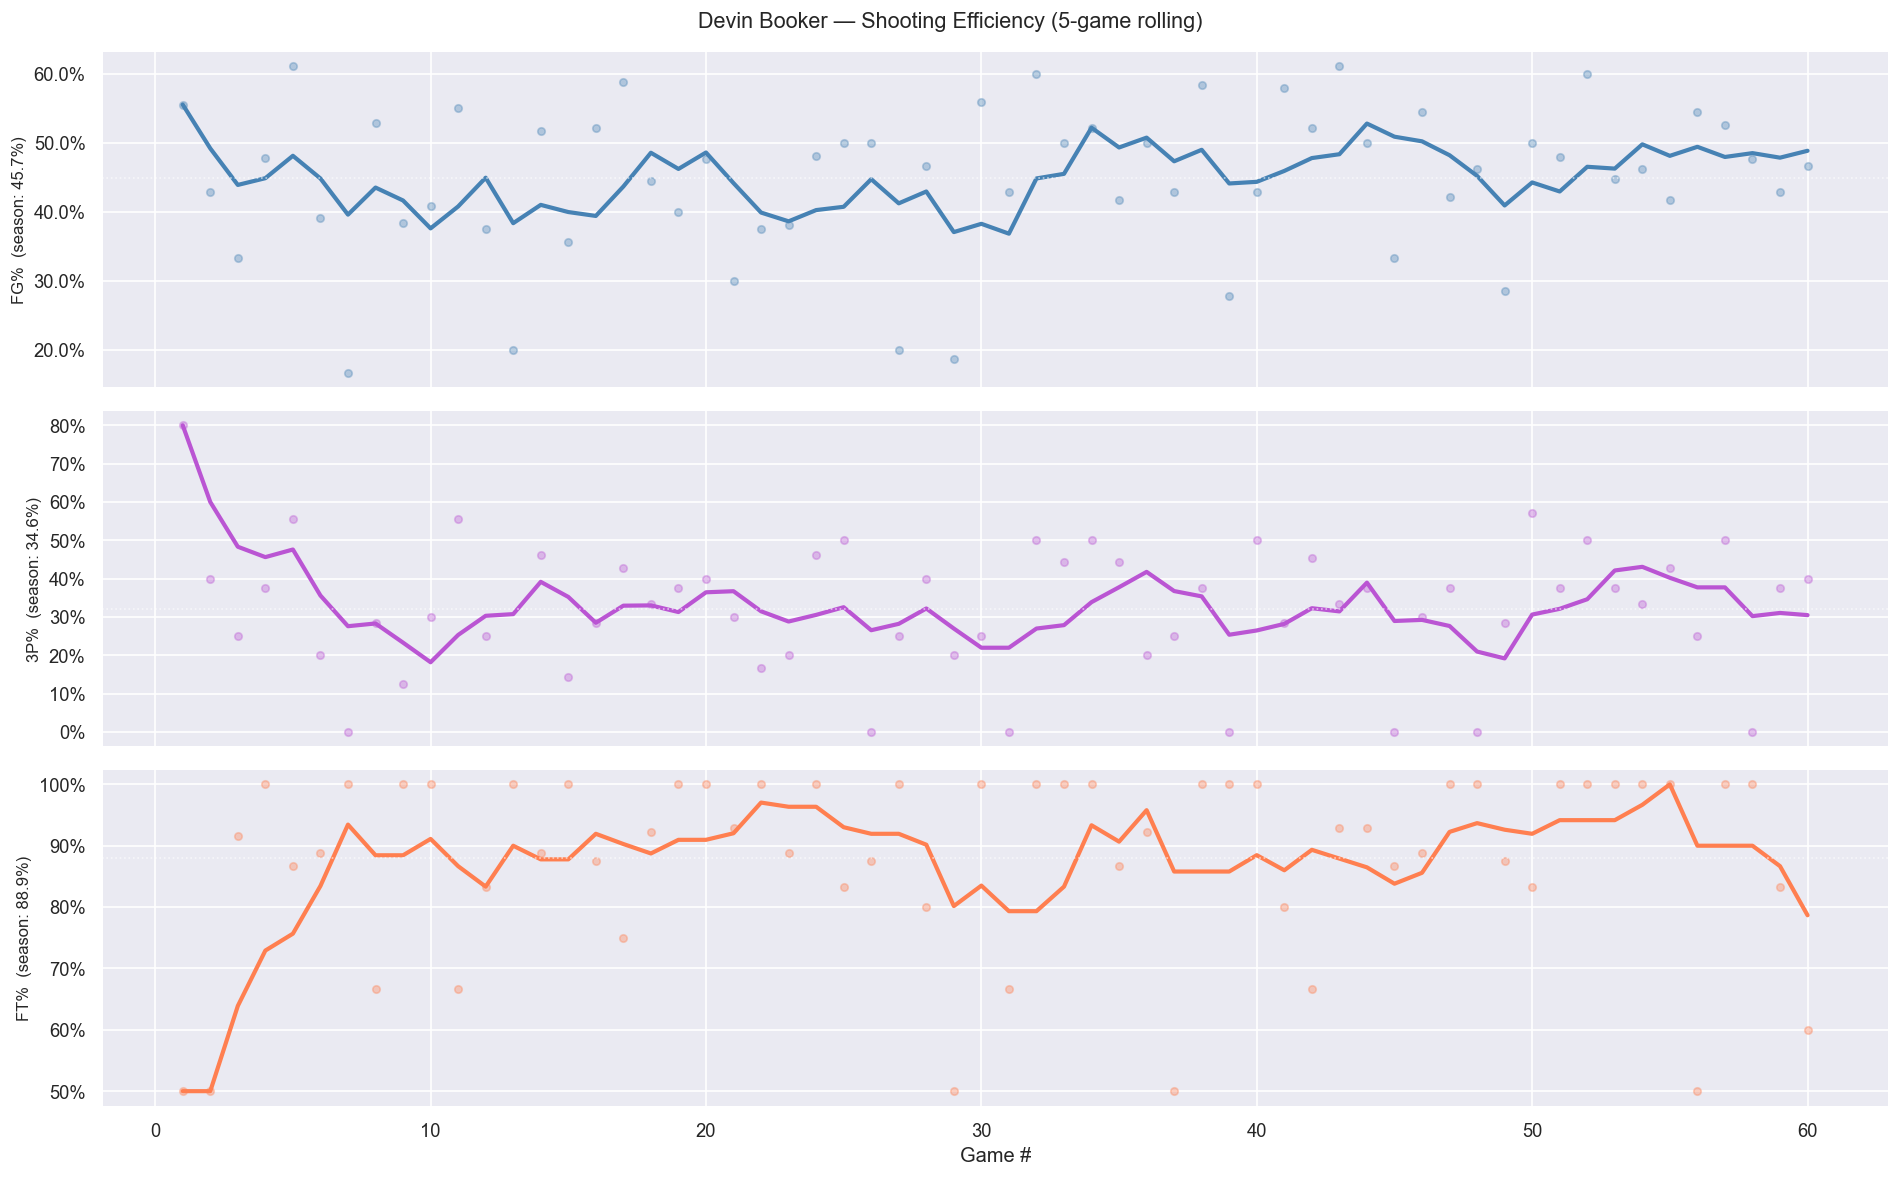

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for ax, col, color, label in [
    (axes[0], 'FG%',  'steelblue',     f'FG%  (season: {fg:.1%})'),
    (axes[1], '3P%',  'mediumorchid',  f'3P%  (season: {tp:.1%})'),
    (axes[2], 'FT%',  'coral',         f'FT%  (season: {ft:.1%})'),
]:
    rolling = df[col].rolling(5, min_periods=1).mean()
    ax.scatter(df['Game'], df[col], alpha=0.35, s=20, color=color)
    ax.plot(df['Game'], rolling, color=color, lw=2.5)
    ax.axhline(df[col].mean(), color='white', lw=1, linestyle=':', alpha=0.6)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.set_ylabel(label, fontsize=10)

axes[2].set_xlabel('Game #')
plt.suptitle('Devin Booker — Shooting Efficiency (5-game rolling)', fontsize=13)
plt.tight_layout()
plt.show()

## Shot Volume vs. Efficiency

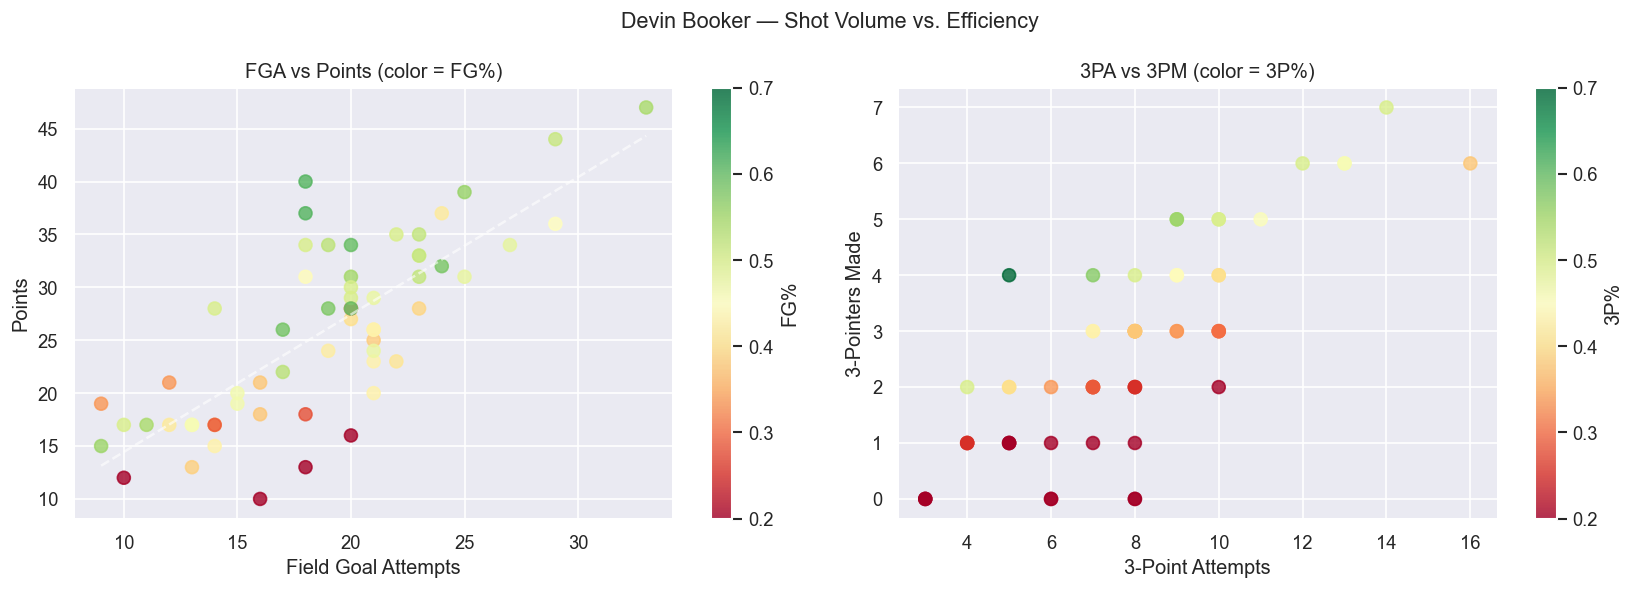

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FGA vs Points scatter
sc = axes[0].scatter(df['FGA'], df['Points'], c=df['FG%'], cmap='RdYlGn',
                     s=60, alpha=0.8, vmin=0.2, vmax=0.7)
plt.colorbar(sc, ax=axes[0], label='FG%')
axes[0].set_xlabel('Field Goal Attempts')
axes[0].set_ylabel('Points')
axes[0].set_title('FGA vs Points (color = FG%)')
# trend line
m, b = np.polyfit(df['FGA'], df['Points'], 1)
x = np.linspace(df['FGA'].min(), df['FGA'].max(), 100)
axes[0].plot(x, m*x + b, 'white', lw=1.5, linestyle='--', alpha=0.6)

# 3PA vs 3PM scatter
sc2 = axes[1].scatter(df['3PA'], df['3PM'], c=df['3P%'], cmap='RdYlGn',
                      s=60, alpha=0.8, vmin=0.2, vmax=0.7)
plt.colorbar(sc2, ax=axes[1], label='3P%')
axes[1].set_xlabel('3-Point Attempts')
axes[1].set_ylabel('3-Pointers Made')
axes[1].set_title('3PA vs 3PM (color = 3P%)')

plt.suptitle('Devin Booker — Shot Volume vs. Efficiency', fontsize=13)
plt.tight_layout()
plt.show()

## Scoring Breakdown — Where Do His Points Come From?

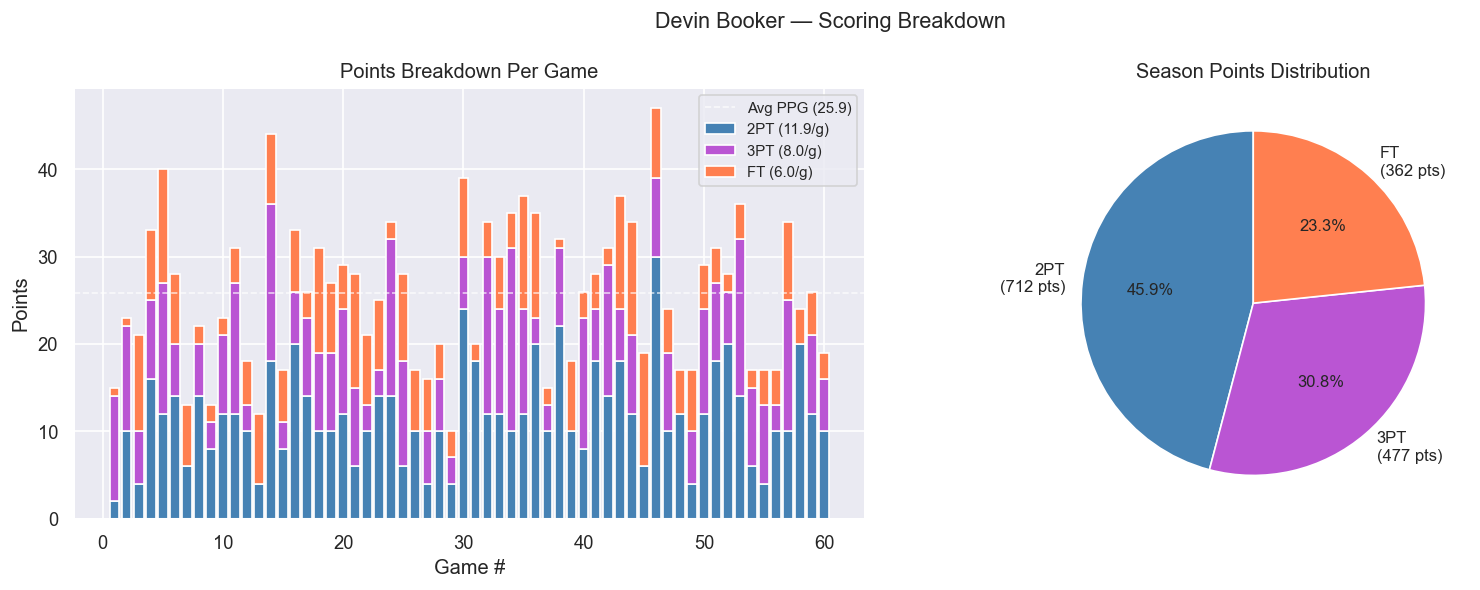

In [7]:
two_pts = (df['FGM'] - df['3PM']) * 2
three_pts = df['3PM'] * 3
ft_pts = df['FT']

avg_2 = two_pts.mean()
avg_3 = three_pts.mean()
avg_ft = ft_pts.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar over season
axes[0].bar(df['Game'], two_pts,              color='steelblue',  label=f'2PT ({avg_2:.1f}/g)')
axes[0].bar(df['Game'], three_pts, bottom=two_pts, color='mediumorchid', label=f'3PT ({avg_3:.1f}/g)')
axes[0].bar(df['Game'], ft_pts, bottom=two_pts+three_pts, color='coral', label=f'FT ({avg_ft:.1f}/g)')
axes[0].axhline(ppg, color='white', lw=1, linestyle='--', alpha=0.7, label=f'Avg PPG ({ppg:.1f})')
axes[0].set_xlabel('Game #')
axes[0].set_ylabel('Points')
axes[0].set_title('Points Breakdown Per Game')
axes[0].legend(fontsize=9)

# Pie chart of season totals
totals = [two_pts.sum(), three_pts.sum(), ft_pts.sum()]
axes[1].pie(totals,
            labels=[f'2PT\n({two_pts.sum():.0f} pts)', f'3PT\n({three_pts.sum():.0f} pts)', f'FT\n({ft_pts.sum():.0f} pts)'],
            colors=['steelblue','mediumorchid','coral'],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Season Points Distribution')

plt.suptitle('Devin Booker — Scoring Breakdown', fontsize=13)
plt.tight_layout()
plt.show()

## Monthly Performance

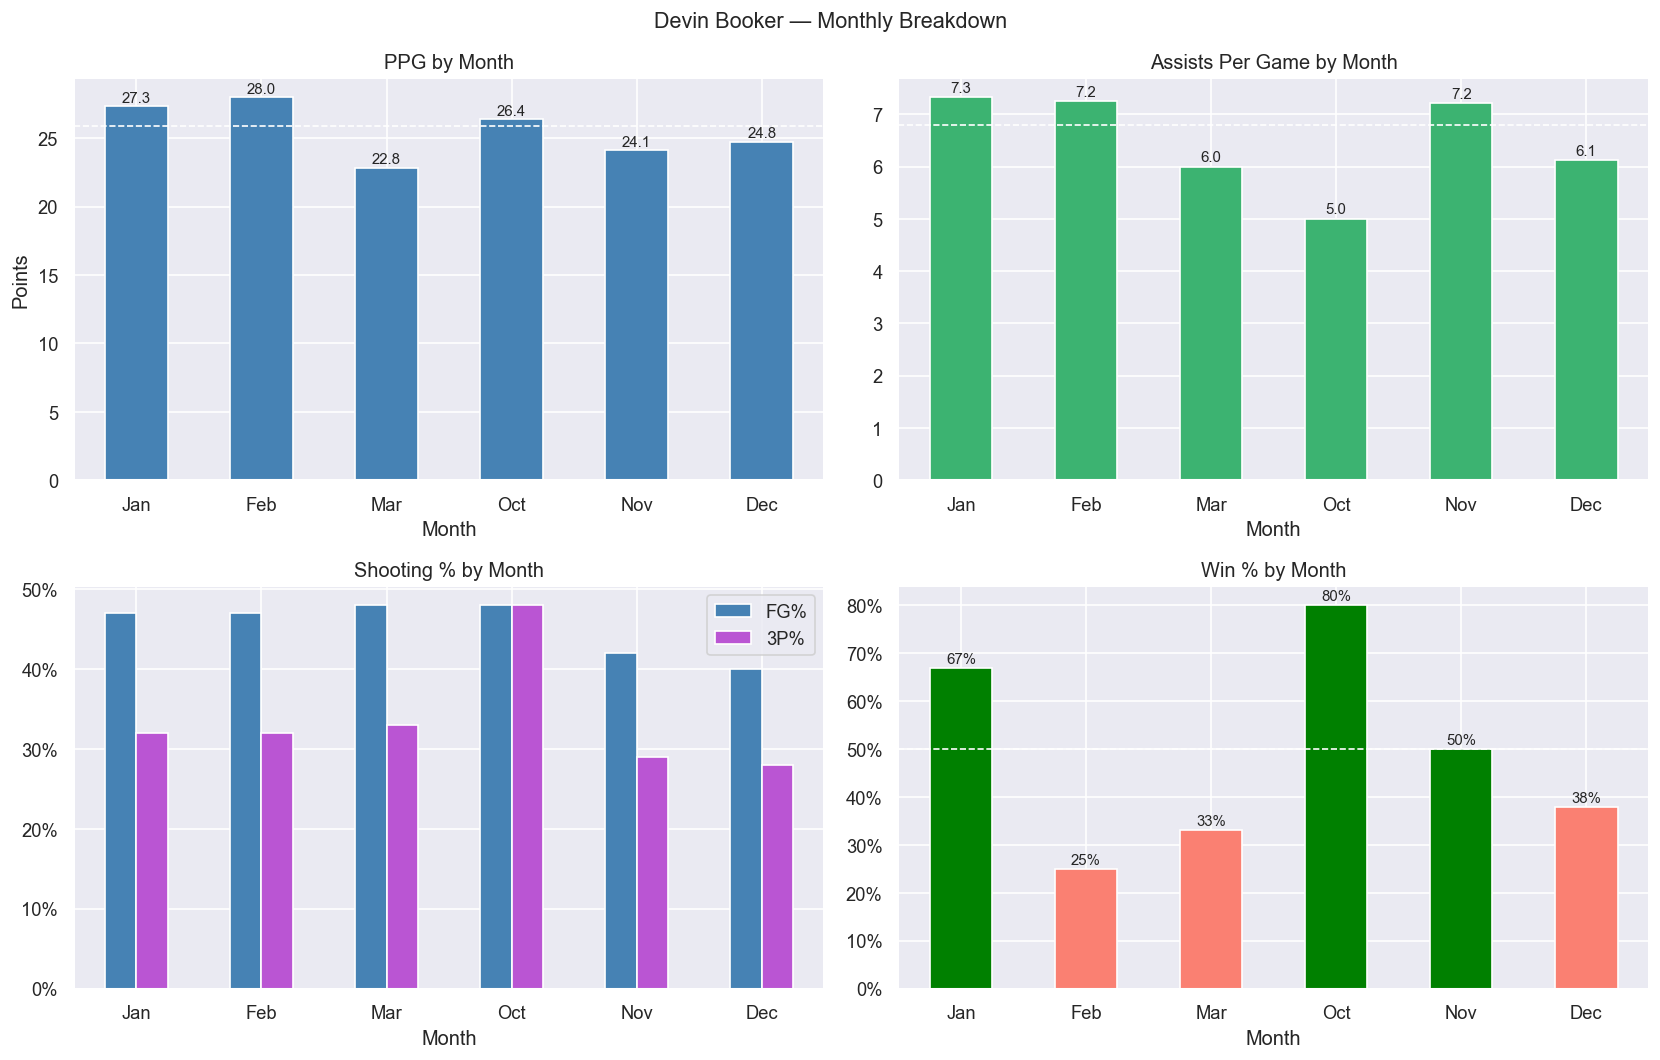

       GP    PPG   APG   RPG  FGpct  TPpct    PM  Win%
Month                                                 
Jan    15  27.33  7.33  4.73   0.47   0.32  3.93  0.67
Feb    12  28.00  7.25  3.67   0.47   0.32 -6.58  0.25
Mar     6  22.83  6.00  5.00   0.48   0.33 -6.33  0.33
Oct     5  26.40  5.00  3.20   0.48   0.48  3.00  0.80
Nov    14  24.14  7.21  3.64   0.42   0.29 -3.57  0.50
Dec     8  24.75  6.12  4.00   0.40   0.28 -0.88  0.38


In [8]:
month_order = df.sort_values('Month_num')['Month'].unique()
monthly = df.groupby('Month').agg(
    GP=('Points','count'),
    PPG=('Points','mean'),
    APG=('Assists','mean'),
    RPG=('TRB','mean'),
    FGpct=('FG%','mean'),
    TPpct=('3P%','mean'),
    PM=('p/m','mean'),
    Wins=('Win','sum')
).round(2).reindex(month_order)
monthly['Win%'] = (monthly['Wins'] / monthly['GP']).round(2)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

monthly['PPG'].plot(kind='bar', ax=axes[0,0], color='steelblue', rot=0)
axes[0,0].axhline(ppg, color='white', lw=1, linestyle='--')
axes[0,0].set_title('PPG by Month')
axes[0,0].set_ylabel('Points')
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{p.get_height():.1f}', (p.get_x()+p.get_width()/2, p.get_height()+0.3),
                       ha='center', fontsize=9)

monthly['APG'].plot(kind='bar', ax=axes[0,1], color='mediumseagreen', rot=0)
axes[0,1].axhline(apg, color='white', lw=1, linestyle='--')
axes[0,1].set_title('Assists Per Game by Month')
for p in axes[0,1].patches:
    axes[0,1].annotate(f'{p.get_height():.1f}', (p.get_x()+p.get_width()/2, p.get_height()+0.1),
                       ha='center', fontsize=9)

monthly[['FGpct','TPpct']].plot(kind='bar', ax=axes[1,0], rot=0,
                                 color=['steelblue','mediumorchid'])
axes[1,0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
axes[1,0].set_title('Shooting % by Month')
axes[1,0].legend(['FG%','3P%'])

monthly['Win%'].plot(kind='bar', ax=axes[1,1],
                     color=['green' if w >= 0.5 else 'salmon' for w in monthly['Win%']], rot=0)
axes[1,1].axhline(0.5, color='white', lw=1, linestyle='--')
axes[1,1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
axes[1,1].set_title('Win % by Month')
for p in axes[1,1].patches:
    axes[1,1].annotate(f'{p.get_height():.0%}', (p.get_x()+p.get_width()/2, p.get_height()+0.01),
                       ha='center', fontsize=9)

plt.suptitle('Devin Booker — Monthly Breakdown', fontsize=13)
plt.tight_layout()
plt.show()

print(monthly[['GP','PPG','APG','RPG','FGpct','TPpct','PM','Win%']].to_string())

## Home vs. Away Splits

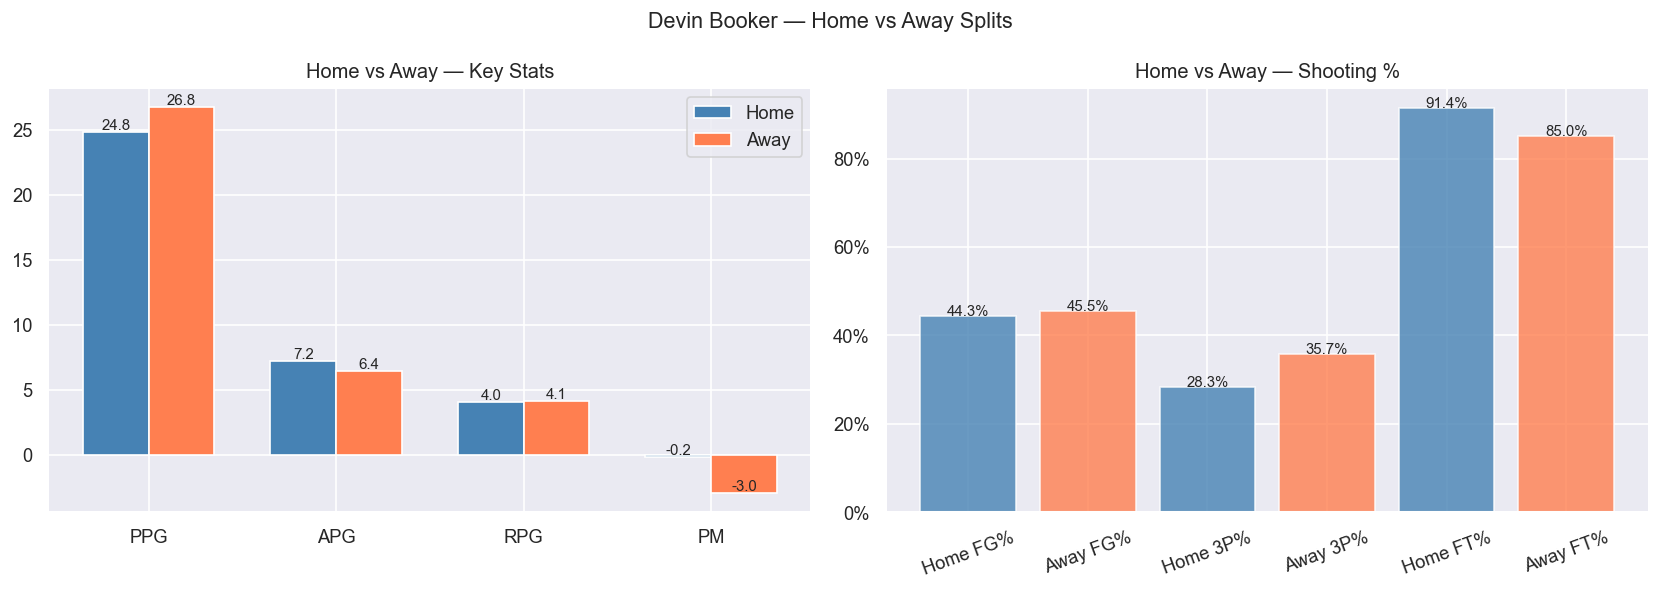

      GP     PPG    APG    RPG  FGpct  TPpct  FTpct     PM  Win_pct
Away  32  26.750  6.438  4.094  0.455  0.357  0.850 -2.969    0.375
Home  28  24.821  7.214  4.036  0.443  0.283  0.914 -0.179    0.607


In [9]:
ha = df.groupby('Home').agg(
    GP=('Points','count'),
    PPG=('Points','mean'),
    APG=('Assists','mean'),
    RPG=('TRB','mean'),
    FGpct=('FG%','mean'),
    TPpct=('3P%','mean'),
    FTpct=('FT%','mean'),
    PM=('p/m','mean'),
    Win_pct=('Win','mean')
).round(3)
ha.index = ['Away', 'Home']

stats_to_plot = ['PPG','APG','RPG','PM']
x = np.arange(len(stats_to_plot))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(x - width/2, ha.loc['Home', stats_to_plot], width, label='Home', color='steelblue')
bars2 = axes[0].bar(x + width/2, ha.loc['Away', stats_to_plot], width, label='Away', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(stats_to_plot)
axes[0].set_title('Home vs Away — Key Stats')
axes[0].legend()
for bar in bars1:
    axes[0].annotate(f'{bar.get_height():.1f}', (bar.get_x()+bar.get_width()/2, bar.get_height()+0.2), ha='center', fontsize=9)
for bar in bars2:
    axes[0].annotate(f'{bar.get_height():.1f}', (bar.get_x()+bar.get_width()/2, bar.get_height()+0.2), ha='center', fontsize=9)

fg_bars = axes[1].bar(['Home FG%','Away FG%','Home 3P%','Away 3P%','Home FT%','Away FT%'],
                       [ha.loc['Home','FGpct'], ha.loc['Away','FGpct'],
                        ha.loc['Home','TPpct'], ha.loc['Away','TPpct'],
                        ha.loc['Home','FTpct'], ha.loc['Away','FTpct']],
                       color=['steelblue','coral','steelblue','coral','steelblue','coral'], alpha=0.8)
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
axes[1].set_title('Home vs Away — Shooting %')
axes[1].tick_params(axis='x', rotation=20)
for bar in fg_bars:
    axes[1].annotate(f'{bar.get_height():.1%}', (bar.get_x()+bar.get_width()/2, bar.get_height()+0.002), ha='center', fontsize=9)

plt.suptitle('Devin Booker — Home vs Away Splits', fontsize=13)
plt.tight_layout()
plt.show()

print(ha[['GP','PPG','APG','RPG','FGpct','TPpct','FTpct','PM','Win_pct']].to_string())

## Performance by Opponent

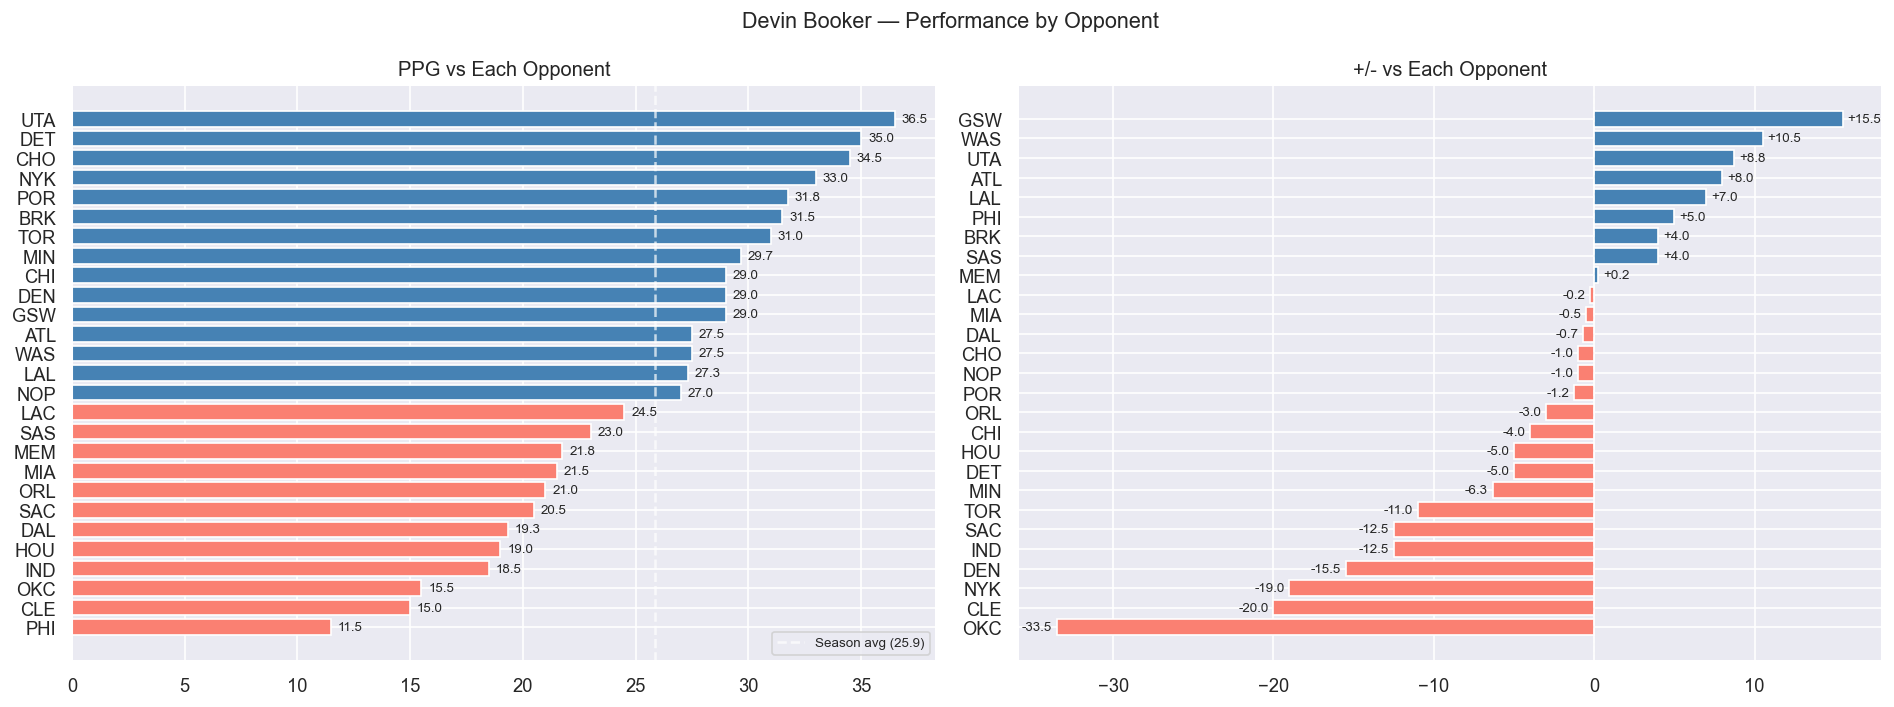

          GP    PPG    APG   RPG  FGpct     PM  Win_pct
Opponent                                               
UTA        4  36.50   6.75  3.75   0.54   8.75     1.00
DET        1  35.00   3.00  5.00   0.50  -5.00     1.00
CHO        2  34.50   9.00  5.50   0.53  -1.00     0.50
NYK        1  33.00   5.00  3.00   0.52 -19.00     0.00
POR        4  31.75   5.75  4.75   0.50  -1.25     0.50
BRK        2  31.50   5.00  2.50   0.51   4.00     0.50
TOR        1  31.00   8.00  4.00   0.48 -11.00     0.00
MIN        3  29.67   6.67  4.67   0.50  -6.33     0.00
CHI        1  29.00   8.00  4.00   0.50  -4.00     1.00
DEN        2  29.00   5.00  6.50   0.47 -15.50     0.00
GSW        2  29.00  10.00  4.00   0.46  15.50     1.00
ATL        2  27.50   8.50  4.00   0.48   8.00     0.50
WAS        2  27.50   6.00  4.50   0.35  10.50     1.00
LAL        3  27.33   5.33  2.67   0.50   7.00     0.67
NOP        3  27.00   6.67  3.67   0.40  -1.00     0.33
LAC        4  24.50   7.50  5.25   0.54  -0.25  

In [10]:
opp = df.groupby('Opponent').agg(
    GP=('Points','count'),
    PPG=('Points','mean'),
    APG=('Assists','mean'),
    RPG=('TRB','mean'),
    FGpct=('FG%','mean'),
    PM=('p/m','mean'),
    Win_pct=('Win','mean')
).round(2).sort_values('PPG', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_ppg = ['steelblue' if p >= ppg else 'salmon' for p in opp['PPG']]
bars = axes[0].barh(opp.index[::-1], opp['PPG'][::-1], color=colors_ppg[::-1])
axes[0].axvline(ppg, color='white', lw=1.5, linestyle='--', alpha=0.7, label=f'Season avg ({ppg:.1f})')
for bar, val in zip(bars, opp['PPG'][::-1]):
    axes[0].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontsize=8)
axes[0].set_title('PPG vs Each Opponent')
axes[0].legend(fontsize=8)

colors_pm = ['steelblue' if p >= 0 else 'salmon' for p in opp['PM']]
bars2 = axes[1].barh(opp.sort_values('PM', ascending=False).index[::-1],
                     opp.sort_values('PM', ascending=False)['PM'][::-1],
                     color=['steelblue' if p >= 0 else 'salmon'
                            for p in opp.sort_values('PM', ascending=False)['PM'][::-1]])
axes[1].axvline(0, color='white', lw=1, linestyle='--', alpha=0.5)
for bar, val in zip(bars2, opp.sort_values('PM', ascending=False)['PM'][::-1]):
    axes[1].text(bar.get_width() + (0.3 if val >= 0 else -0.3),
                 bar.get_y()+bar.get_height()/2,
                 f'{val:+.1f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
axes[1].set_title('+/- vs Each Opponent')

plt.suptitle('Devin Booker — Performance by Opponent', fontsize=13)
plt.tight_layout()
plt.show()

print(opp.to_string())

## Plus/Minus & Win Correlation

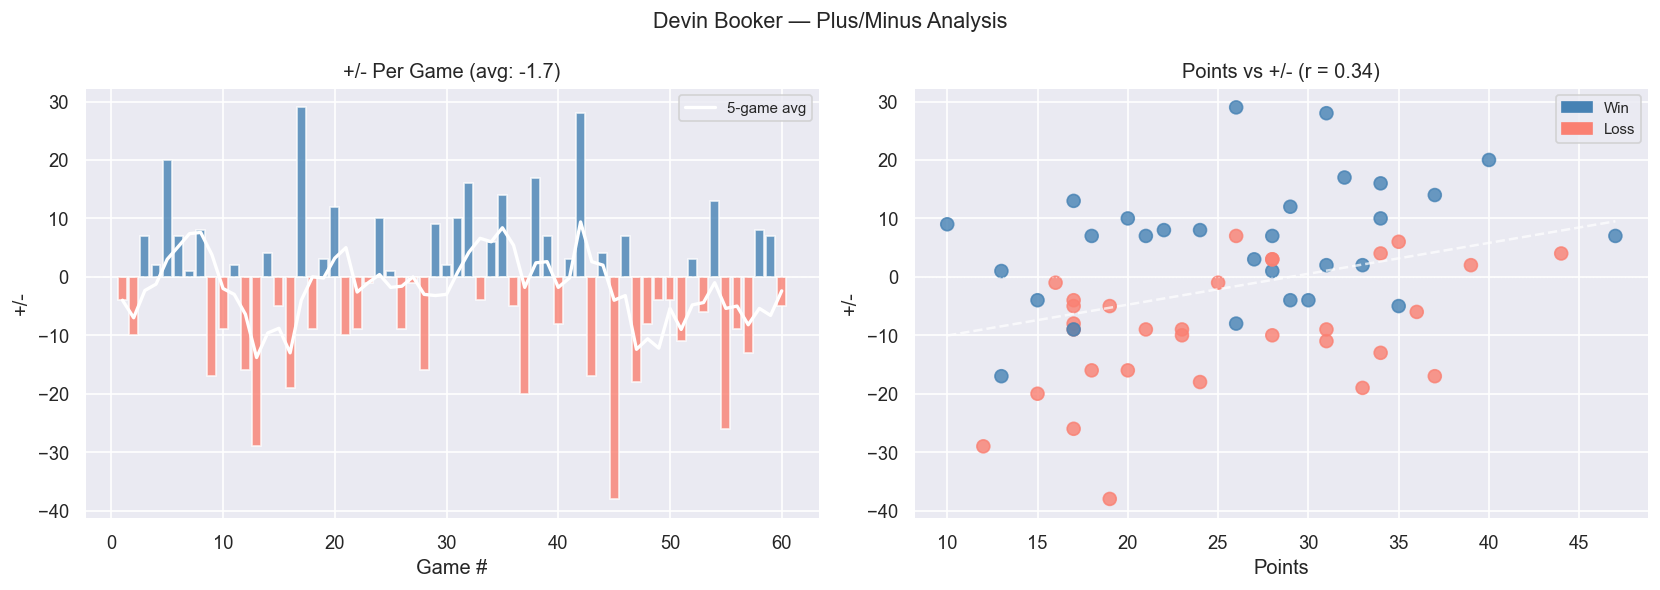

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plus/minus over season
pm_colors = ['steelblue' if p >= 0 else 'salmon' for p in df['p/m']]
axes[0].bar(df['Game'], df['p/m'], color=pm_colors, alpha=0.8)
axes[0].plot(df['Game'], df['p/m'].rolling(5, min_periods=1).mean(),
             color='white', lw=2, label='5-game avg')
axes[0].axhline(0, color='white', lw=1, linestyle='--', alpha=0.5)
axes[0].set_xlabel('Game #')
axes[0].set_ylabel('+/-')
axes[0].set_title(f'+/- Per Game (avg: {pm:+.1f})')
axes[0].legend(fontsize=9)

# Points vs +/- scatter
sc = axes[1].scatter(df['Points'], df['p/m'],
                     c=['steelblue' if w else 'salmon' for w in df['Win']],
                     s=60, alpha=0.8)
m2, b2 = np.polyfit(df['Points'], df['p/m'], 1)
xline = np.linspace(df['Points'].min(), df['Points'].max(), 100)
axes[1].plot(xline, m2*xline+b2, 'white', lw=1.5, linestyle='--', alpha=0.7)
axes[1].axhline(0, color='white', lw=0.8, linestyle=':', alpha=0.5)
blue_p = mpatches.Patch(color='steelblue', label='Win')
red_p  = mpatches.Patch(color='salmon',    label='Loss')
axes[1].legend(handles=[blue_p, red_p], fontsize=9)
axes[1].set_xlabel('Points')
axes[1].set_ylabel('+/-')
corr = df['Points'].corr(df['p/m'])
axes[1].set_title(f'Points vs +/- (r = {corr:.2f})')

plt.suptitle('Devin Booker — Plus/Minus Analysis', fontsize=13)
plt.tight_layout()
plt.show()

## Stats in Wins vs Losses

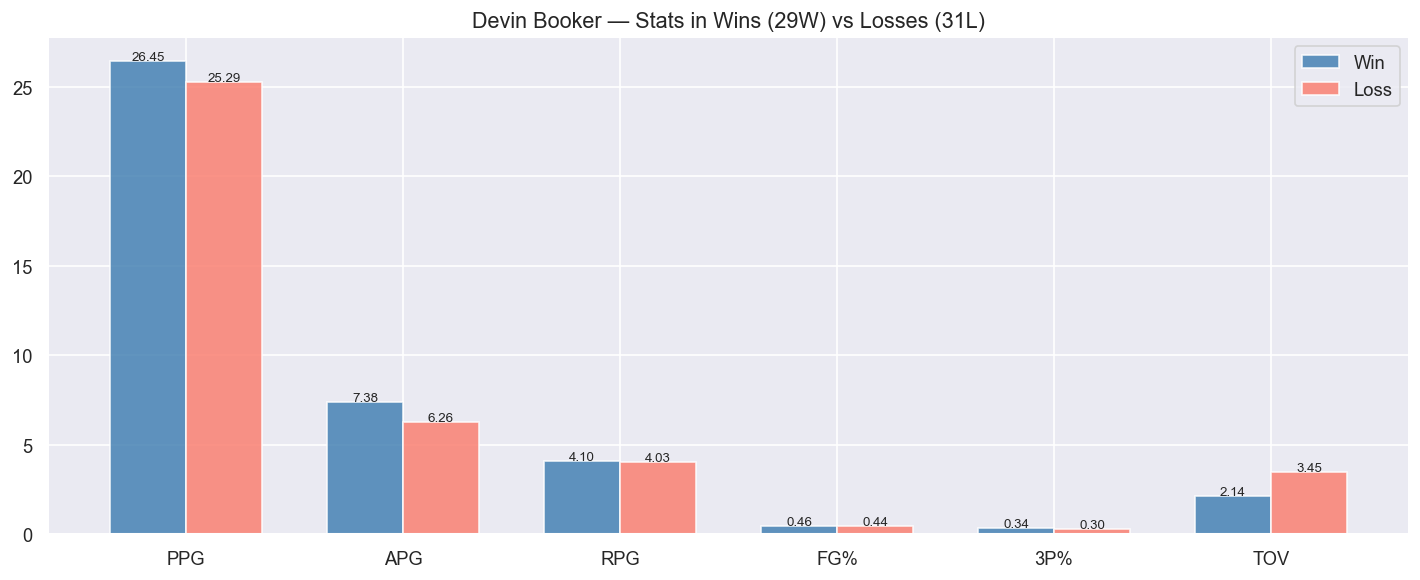

In [12]:
wl = df.groupby('Win').agg(
    GP=('Points','count'),
    PPG=('Points','mean'),
    APG=('Assists','mean'),
    RPG=('TRB','mean'),
    FGpct=('FG%','mean'),
    TPpct=('3P%','mean'),
    TOV=('Turnovers','mean'),
    MIN=('Minutes','mean')
).round(2)
wl.index = ['Loss', 'Win']

stats = ['PPG','APG','RPG','FGpct','TPpct','TOV']
x = np.arange(len(stats))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_w = ax.bar(x - width/2, wl.loc['Win', stats],  width, label='Win',  color='steelblue', alpha=0.85)
bars_l = ax.bar(x + width/2, wl.loc['Loss', stats], width, label='Loss', color='salmon',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['PPG','APG','RPG','FG%','3P%','TOV'])
ax.legend()
ax.set_title(f'Devin Booker — Stats in Wins ({int(wins)}W) vs Losses ({int(gp-wins)}L)', fontsize=13)
for bar in list(bars_w) + list(bars_l):
    ax.annotate(f'{bar.get_height():.2f}', (bar.get_x()+bar.get_width()/2, bar.get_height()+0.05),
                ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## Hot & Cold Streaks

In [13]:
# Best and worst 5-game stretches
roll5 = df['Points'].rolling(5).mean()
best_end  = roll5.idxmax()
worst_end = roll5.idxmin()

print('=== BEST 5-GAME STRETCH ===')
print(df.loc[best_end-4:best_end, ['Date','Opponent','Points','Assists','FG%','Win']].to_string(index=False))
print(f"  → Avg: {roll5[best_end]:.1f} PPG")

print()
print('=== WORST 5-GAME STRETCH ===')
print(df.loc[worst_end-4:worst_end, ['Date','Opponent','Points','Assists','FG%','Win']].to_string(index=False))
print(f"  → Avg: {roll5[worst_end]:.1f} PPG")

print()
print('=== SINGLE GAME HIGHS ===')
for col in ['Points','Assists','TRB','3PM','FT']:
    idx = df[col].idxmax()
    print(f"  {col:<10} {int(df.loc[idx, col])} — vs {df.loc[idx,'Opponent']} on {df.loc[idx,'Date'].date()}")

=== BEST 5-GAME STRETCH ===
      Date Opponent  Points  Assists      FG%   Win
2025-01-11      UTA      34        4 0.600000  True
2025-01-12      CHO      30        8 0.500000  True
2025-01-14      ATL      35        5 0.521739 False
2025-01-16      WAS      37        5 0.416667  True
2025-01-18      DET      35        3 0.500000  True
  → Avg: 34.2 PPG

=== WORST 5-GAME STRETCH ===
      Date Opponent  Points  Assists      FG%   Win
2024-12-15      POR      28        5 0.500000  True
2024-12-19      IND      17        6 0.500000 False
2024-12-31      MEM      16        9 0.200000 False
2025-01-04      IND      20        9 0.466667 False
2025-01-06      PHI      10       10 0.187500  True
  → Avg: 18.2 PPG

=== SINGLE GAME HIGHS ===
  Points     47 — vs UTA on 2025-02-07
  Assists    12 — vs DAL on 2024-11-08
  TRB        9 — vs POR on 2024-11-02
  3PM        7 — vs ATL on 2025-01-14
  FT         13 — vs LAC on 2024-10-31


## Stat Correlation Heatmap

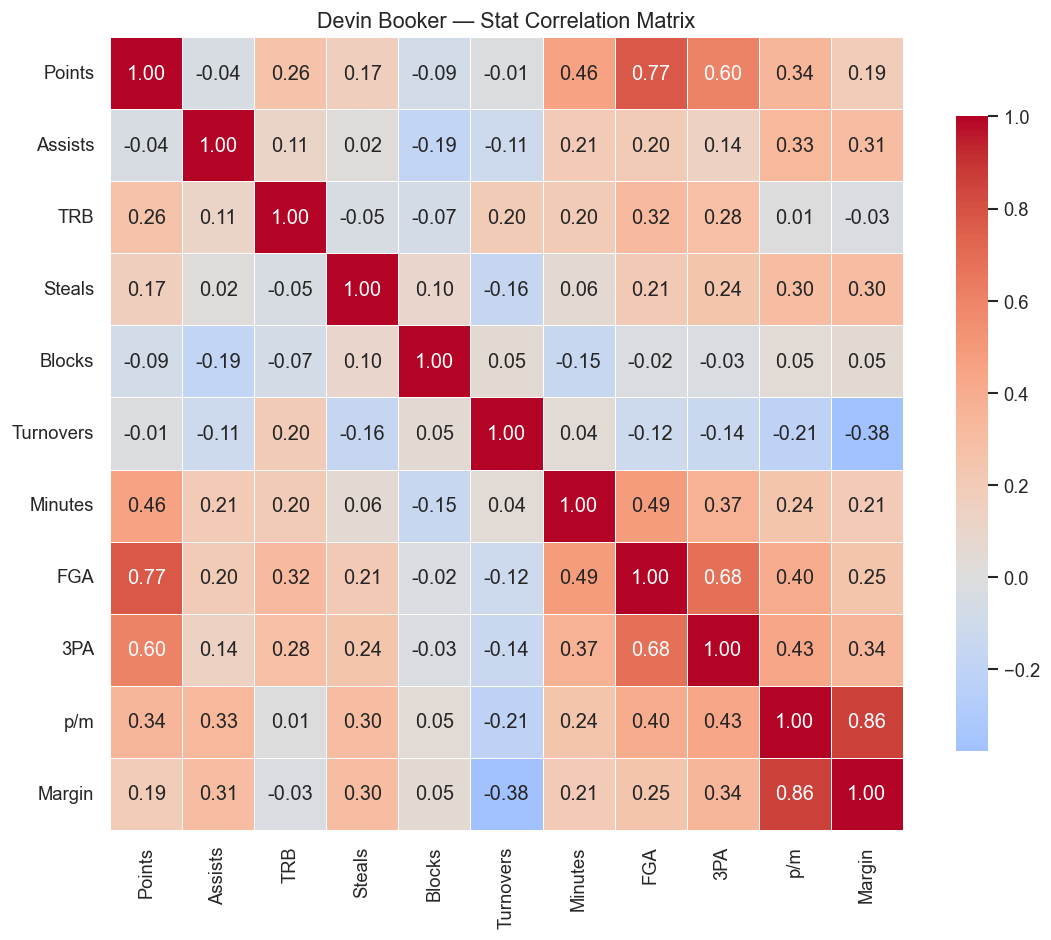

In [14]:
corr_cols = ['Points','Assists','TRB','Steals','Blocks','Turnovers','Minutes','FGA','3PA','p/m','Margin']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Devin Booker — Stat Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## Full Game Log

In [15]:
log = df[['Date','Opponent','Home','Win','Minutes','Points','Assists','TRB',
          'Steals','Blocks','Turnovers','FGA','FGM','FG%','3PA','3PM','3P%','FT','FTA','FT%','p/m']].copy()
log['Home'] = log['Home'].map({True:'Home', False:'Away'})
log['Win']  = log['Win'].map({True:'W', False:'L'})
log['FG%']  = log['FG%'].map('{:.1%}'.format)
log['3P%']  = log['3P%'].map(lambda x: f'{x:.1%}' if pd.notna(x) else '-')
log['FT%']  = log['FT%'].map(lambda x: f'{x:.1%}' if pd.notna(x) else '-')
log['Date'] = log['Date'].dt.date
log = log.reset_index(drop=True)
log.index += 1
log

,Date,Opponent,Home,Win,Minutes,Points,Assists,TRB,Steals,Blocks,...,FGA,FGM,FG%,3PA,3PM,3P%,FT,FTA,FT%,p/m
1,2024-10-23,LAC,Away,W,32.13,15,6,4,1,1,...,9,5,55.6%,5,4,80.0%,1,2,50.0%,-4
2,2024-10-25,LAL,Away,L,35.33,23,4,3,1,1,...,21,9,42.9%,10,4,40.0%,1,2,50.0%,-10
3,2024-10-26,DAL,Home,W,37.08,21,5,1,1,0,...,12,4,33.3%,8,2,25.0%,11,12,91.7%,7
4,2024-10-28,LAL,Home,W,39.42,33,2,3,1,0,...,23,11,47.8%,8,3,37.5%,8,8,100.0%,2
5,2024-10-31,LAC,Away,W,37.77,40,8,5,3,0,...,18,11,61.1%,9,5,55.6%,13,15,86.7%,20
6,2024-11-02,POR,Home,W,36.03,28,9,9,0,0,...,23,9,39.1%,10,2,20.0%,8,9,88.9%,7
7,2024-11-04,PHI,Home,W,38.22,13,6,3,1,1,...,18,3,16.7%,6,0,0.0%,7,7,100.0%,1
8,2024-11-06,MIA,Home,W,38.88,22,9,4,0,0,...,17,9,52.9%,7,2,28.6%,2,3,66.7%,8
9,2024-11-08,DAL,Away,W,34.53,13,12,6,0,0,...,13,5,38.5%,8,1,12.5%,2,2,100.0%,-17
10,2024-11-10,SAC,Home,L,43.27,23,12,1,2,0,...,22,9,40.9%,10,3,30.0%,2,2,100.0%,-9
